In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from collections import defaultdict
import copy
import os
import pprint
from pathlib import Path

import hydra
from omegaconf import OmegaConf
from einops import rearrange, reduce
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sqlalchemy as sa
import seaborn as sns
import lightning.pytorch
import torch
import torch.nn as nn
import polars as pl
from tqdm import tqdm

from conf import conf
from g_led import datasets, utils, main_sequential
from g_led.transformer.sequentialModel import SequentialModel as Transformer

In [3]:
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

In [54]:
with hydra.initialize(version_base=utils.HYDRA_INIT['version_base'], config_path='../conf'):
    cfg = hydra.compose(utils.HYDRA_INIT['config_name'], overrides=[
        'dataset=KuramotoSivashinsky1DSize1',
        'model=TransformerKuramotoSivashinsky1D',
        # 'dataset.time_step_window_size_train=65',
        # 'model.time_step_window_size=384',

        # 'dataset.trajectory_count_train=210',
        # 'dataset.trajectory_count_val=190',
        # 'dataset.trajectory_count_test=190',
        # 'dataset.trajectories_are_shared_across_splits=False',
        # 'dataset.trajectory_time_step_size_micro=0.025',
        # 'dataset.trajectory_time_step_count_micro=3840',
        # 'dataset.trajectory_time_step_count_drop_first_micro=1000',
        # 'dataset.trajectory_time_step_subsample_interval_macro=10',

        'dataset.trajectory_count_train=1',
        'dataset.trajectory_count_val=1',
        'dataset.trajectory_count_test=1',
        'dataset.trajectories_are_shared_across_splits=True',
        'dataset.trajectory_time_step_size_micro=0.25',
        'dataset.trajectory_time_step_count_micro=6000',
        'dataset.trajectory_time_step_count_drop_first_micro=2000',
        'dataset.trajectory_time_step_subsample_interval_macro=1',
        'dataset.coarse_dimension=64',
    ])
    engine = conf.get_engine()
    conf.orm.create_all(engine)
    with conf.sa.orm.Session(engine) as db:
        cfg = conf.orm.instantiate_and_insert_config(db, OmegaConf.to_container(cfg, resolve=True))
        cfg_dataset = cfg.dataset
        pprint.pp(cfg_dataset)
        
        lightning.pytorch.seed_everything(cfg.rng_seed)
        with lightning.pytorch.utilities.seed.isolate_rng():
            dataset = datasets.get_dataset(cfg_dataset)
            dataset.prepare_data()
            dataset.setup('fit')

        # cfg = db.execute(sa.select(conf.Conf).filter_by(alt_id='ma688j5t')).first()[0]
        cfg = db.execute(sa.select(conf.Conf).filter_by(alt_id='onlnan23')).first()[0]
        with lightning.pytorch.utilities.seed.isolate_rng():
            model = Transformer(cfg.model, cfg_dataset.solution_dimension * cfg_dataset.embedding_dimension)
        # checkpoint = torch.load(cfg.run_dir/'last.ckpt')
        # model.load_state_dict(checkpoint)
        # train_sequential = main_sequential.TrainSequential(cfg=cfg, down_sampler=datasets.DownSampler(cfg_dataset), model=model)
        train_sequential = main_sequential.TrainSequential.load_from_checkpoint(cfg.run_dir/'last.ckpt', cfg=cfg, down_sampler=datasets.DownSampler(cfg_dataset), model=model)
        # train_sequential.eval()

KuramotoSivashinsky1D(_data_dir='/mnta/taosData/diffusion-dynamics/G-LED/data',
                      rng_seed=2376999025,
                      _processed_filename='ly32adlg',
                      trajectory_count_train=1,
                      trajectory_count_val=1,
                      trajectory_count_test=1,
                      trajectories_are_shared_across_splits=True,
                      trajectory_time_step_size_micro=0.25,
                      trajectory_time_step_count_micro=6000,
                      trajectory_time_step_count_drop_first_micro=2000,
                      trajectory_time_step_subsample_interval_macro=1,
                      macro_time_step_count_train=None,
                      macro_time_step_count_val=None,
                      macro_time_step_count_test=None,
                      time_step_window_size_train=384,
                      time_step_window_size_val=384,
                      time_step_window_size_test=384,
                      bat

Seed set to 2376999025


In [55]:
with torch.no_grad():
    trajectory = 0
    warm_up = 64
    forecast_time = 20
    true = train_sequential.down_sampler(dataset.train[[trajectory], :warm_up+forecast_time]).to(train_sequential.device)
    data = dict(
        true=true,
        pred=train_sequential.forecast(
            forecast_time,
            true[:, :warm_up]
        )
    )
data = {k: v.cpu().numpy() for k, v in data.items()}
data['pred minus true'] = data['pred'] - data['true']
for k, v in data.items():
    print(k, v.shape)

true (1, 84, 64)
pred (1, 84, 64)
pred minus true (1, 84, 64)


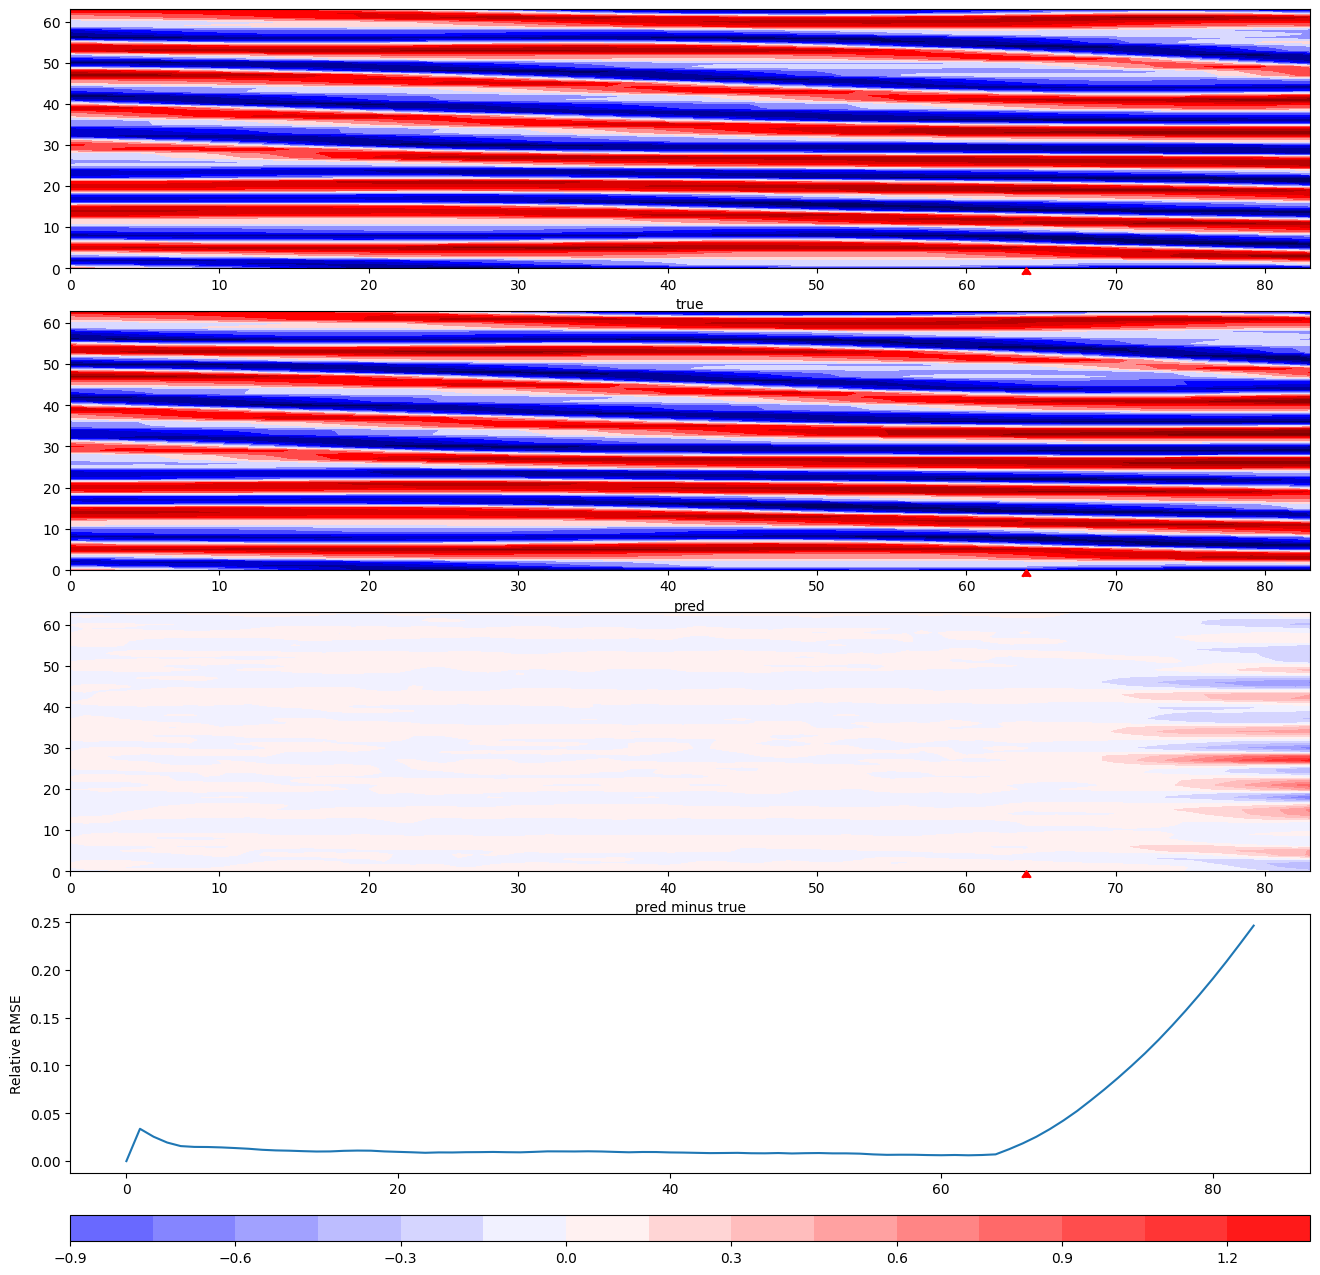

In [56]:
v_min = None
v_max = None
p = .01
for v in data.values():
    _v_min = np.quantile(v, p)
    _v_max = np.quantile(v, 1 - p)
    if v_min is None or v_min > _v_min:
        v_min = _v_min
    if v_max is None or v_max > _v_max:
        v_max = _v_max
v_abs_max = max(map(abs, (v_min, v_max)))
fig, axs = plt.subplots(
    figsize=(16, 4 * (len(data) + 1)),
    height_ratios=[*([10] * (len(data) + 1)), 1],
    nrows=len(data) + 2,
)
for i, (k, trajectory) in enumerate(data.items()):
    trajectory = rearrange(trajectory, '1 time dim -> time dim')
    ax_marker = axs[i].twinx()
    ax_marker.axis('off')
    ax_marker.set_ylim(0, 1)
    ax_marker.scatter([warm_up, warm_up], [0, 0], color='red', marker=6, clip_on=False)
    # im_out = axs[i].imshow(trajectory, cmap='RdBu', vmin=-v_abs_max, vmax=v_abs_max, aspect='auto')
    n, s = np.meshgrid(np.arange(trajectory.shape[0]), np.arange(trajectory.shape[1]))
    # print(n.shape, s.shape, trajectory.shape)
    contourf = axs[i].contourf(n, s, trajectory.T, 15, cmap=plt.get_cmap("seismic"), vmin=-v_abs_max, vmax=v_abs_max)
    axs[i].set_xlabel(k)
axs[-2].plot(
    np.sqrt(reduce(np.square(data['pred minus true']), '1 time dim -> time', 'mean'))
    /
    np.sqrt(reduce(np.square(data['true']), '1 time dim -> time', 'mean'))
)
axs[-2].set_ylabel('Relative RMSE')
fig.colorbar(contourf, cax=axs[-1], orientation='horizontal')